In [8]:
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# ============================================================
# 1. LOAD PLACEMENT PREDICTION DATASET
# ============================================================
project_root = Path.cwd().resolve()
if (project_root / "data").exists():
    data_dir = project_root / "data"
else:
    data_dir = project_root.parent / "data"

df = pd.read_csv(data_dir / "placement_predict_50k Dataset_final.csv")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print("==========================================")
print("           DATASET INFORMATION")
print("==========================================")

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
df.info()


# ============================================================
# 2. HANDLE MISSING VALUES
# ============================================================

print("\n==========================================")
print("           MISSING VALUES")
print("==========================================")

print(df.isnull().sum())


# ============================================================
# 3. ENCODE TARGET VARIABLE
# ============================================================

# PlacementStatus:
# No  -> 0
# Yes -> 1
# The project dataset may already contain 0/1 values, so normalize both forms.
df["PlacementStatus"] = df["PlacementStatus"].replace({
    "No": 0,
    "Yes": 1,
    0: 0,
    1: 1
}).astype(int)

# Check target values
print("\nPlacement Status Values:")
print(df["PlacementStatus"].value_counts())


# ============================================================
# 4. ENCODE HISTORY OF BACKLOGS
# ============================================================

# HistoryOfBacklogs:
# No  -> 0
# Yes -> 1
df["HistoryOfBacklogs"] = df["HistoryOfBacklogs"].replace({
    "No": 0,
    "Yes": 1,
    0: 0,
    1: 1
}).astype(int)


# ============================================================
# 5. DEFINE FEATURES AND TARGET
# ============================================================

# StudentID is only an identifier.
#
# Salary Package is excluded because salary is known only
# after placement and would cause data leakage.
#
# IsAnomaly is also excluded because it is not a normal
# student feature for placement prediction.

X = df.drop(
    [
        "StudentID",
        "PlacementStatus",
        "Salary Package",
        "IsAnomaly"
    ],
    axis=1
)

y = df["PlacementStatus"]


print("\n==========================================")
print("              FEATURES")
print("==========================================")

print(X.columns.tolist())

print("\nNumber of Features Before Encoding:", X.shape[1])


# ============================================================
# 6. IDENTIFY CATEGORICAL AND NUMERICAL COLUMNS
# ============================================================

categorical_columns = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    exclude=["object", "string"]
).columns.tolist()

print("\nCategorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)


# ============================================================
# 7. PREPROCESSING
# ============================================================

# Impute missing values and one-hot encode categorical columns.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))
                ]
            ),
            categorical_columns
        ),
        (
            "numerical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median"))
                ]
            ),
            numerical_columns
        )
    ]
)


# ============================================================
# 8. TRAIN-VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\n==========================================")
print("           TRAIN / VALIDATION")
print("==========================================")

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))


# ============================================================
# 9. BOOSTING BENCHMARK FUNCTION
# ============================================================

def boosting_benchmark(X_train, y_train, X_val, y_val):

    models = {
        "AdaBoost": AdaBoostClassifier(
            n_estimators=100,
            learning_rate=0.1,
            random_state=42
        ),

        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ),

        "XGBoost": XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            eval_metric="logloss"
        ),

        "LightGBM": LGBMClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            verbosity=-1
        )
    }

    results = []

    for name, model in models.items():
        print("\n------------------------------------------")
        print("Training:", name)
        print("------------------------------------------")

        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", model)
            ]
        )

        pipeline.fit(X_train, y_train)

        train_pred = pipeline.predict(X_train)
        val_pred = pipeline.predict(X_val)

        train_accuracy = accuracy_score(y_train, train_pred)
        val_accuracy = accuracy_score(y_val, val_pred)

        print("Training Accuracy:", round(train_accuracy * 100, 2), "%")
        print("Validation Accuracy:", round(val_accuracy * 100, 2), "%")

        results.append({
            "Model": name,
            "Training Accuracy": train_accuracy,
            "Validation Accuracy": val_accuracy
        })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(
        by="Validation Accuracy",
        ascending=False
    ).reset_index(drop=True)

    return results_df


# ============================================================
# 10. RUN BOOSTING BENCHMARK
# ============================================================

results = boosting_benchmark(
    X_train,
    y_train,
    X_val,
    y_val
)


# ============================================================
# 11. DISPLAY FINAL RESULTS
# ============================================================

print("\n\n==========================================")
print("       BOOSTING BENCHMARK RESULTS")
print("==========================================")

display_results = results.copy()
display_results["Training Accuracy"] = (
    display_results["Training Accuracy"] * 100
).round(2)

display_results["Validation Accuracy"] = (
    display_results["Validation Accuracy"] * 100
).round(2)

display_results = display_results.rename(
    columns={
        "Training Accuracy": "Training Accuracy (%)",
        "Validation Accuracy": "Validation Accuracy (%)"
    }
)

print(display_results.to_string(index=False))


# ============================================================
# 12. DISPLAY BEST MODEL
# ============================================================

best_model = results.iloc[0]

print("\n==========================================")
print("              BEST MODEL")
print("==========================================")

print("Model:", best_model["Model"])
print("Training Accuracy:", round(best_model["Training Accuracy"] * 100, 2), "%")
print("Validation Accuracy:", round(best_model["Validation Accuracy"] * 100, 2), "%")

print("==========================================")

           DATASET INFORMATION
Dataset Shape: (50000, 32)

Column Names:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']

First 5 Rows:
   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    D

Dataset:
     ID  CGPA  Internships Backlogs  Aptitude Placed
0    S1   8.6            2       No        73    Yes
1    S2   9.4            2       No        76    Yes
2    S3   9.0            2       No        81    Yes
3    S4   5.2            0      Yes        48     No
4    S5   5.3            0      Yes        44     No
5    S6   5.0            1       No        83     No
6    S7   6.2            1      Yes        63     No
7    S8   6.2            0      Yes        52    Yes
8    S9   8.7            2      Yes        77    Yes
9   S10   7.5            1       No        70    Yes
10  S11   6.7            1       No        96    Yes
11  S12   7.5            1       No        84    Yes
12  S13   6.8            0      Yes        48     No
13  S14   6.8            0       No        73     No

Features:
    CGPA  Internships  Backlogs  Aptitude
0    8.6            2         0        73
1    9.4            2         0        76
2    9.0            2         0        81
3    5.2         

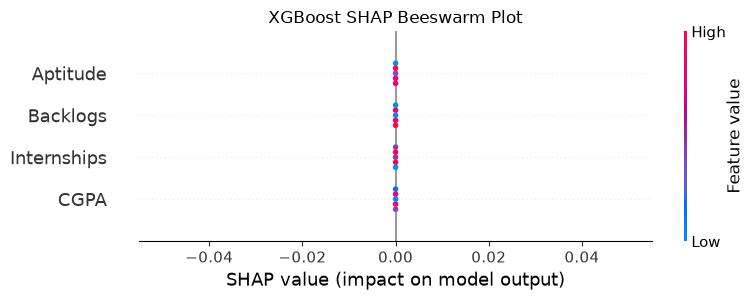


BOOSTING BENCHMARK RESULTS
      model  train_accuracy  val_accuracy  training_time_sec
0  AdaBoost        1.000000           0.8           0.207762
1       GBC        1.000000           0.6           0.091179
2       XGB        0.555556           0.6           0.109838
3       LGB        0.555556           0.6           0.010961


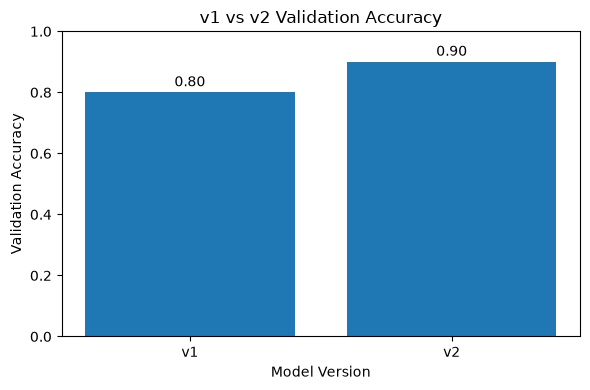

In [9]:
# ============================================================
# BOOSTING BENCHMARK - PLACEMENT PREDICTION
# ============================================================

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap


# ============================================================
# 1. LOAD DATASET
# ============================================================
project_root = Path.cwd().resolve()
if (project_root / "data").exists():
    data_dir = project_root / "data"
else:
    data_dir = project_root.parent / "data"

df = pd.read_csv(data_dir / "DT_Placement.csv")

print("Dataset:")
print(df)


# ============================================================
# 2. ENCODE CATEGORICAL VARIABLES
# ============================================================

df["Backlogs"] = df["Backlogs"].replace({
    "No": 0,
    "Yes": 1,
    0: 0,
    1: 1
}).astype(int)

df["Placed"] = df["Placed"].replace({
    "No": 0,
    "Yes": 1,
    0: 0,
    1: 1
}).astype(int)


# ============================================================
# 3. FEATURES AND TARGET
# ============================================================

X = df.drop(["ID", "Placed"], axis=1)
y = df["Placed"]

# Fill missing values before fitting any model.
cat_cols = X.select_dtypes(include=["object", "string"]).columns
num_cols = X.select_dtypes(exclude=["object", "string"]).columns

for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode().iloc[0])

for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

print("\nFeatures:")
print(X)

print("\nTarget:")
print(y)


# ============================================================
# 4. TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_val))


# ============================================================
# 5. ADABOOST - SAMPLE WEIGHTS
# ============================================================

ada = AdaBoostClassifier(
    n_estimators=10,
    learning_rate=0.5,
    random_state=42
)

# Initial equal weights
initial_weights = np.ones(len(X_train)) / len(X_train)

print("\nInitial AdaBoost sample weights:")
print(initial_weights)

ada.fit(X_train, y_train)

# Prediction
ada_pred = ada.predict(X_val)

print("\nAdaBoost Validation Accuracy:",
      accuracy_score(y_val, ada_pred))


# ============================================================
# 6. DISPLAY ADABOOST ESTIMATOR WEIGHTS
# ============================================================

print("\nAdaBoost estimator weights:")

for i, weight in enumerate(ada.estimator_weights_):
    print(f"Estimator {i + 1}: {weight:.4f}")


# ============================================================
# 7. XGBOOST WITH EARLY STOPPING
# ============================================================

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="logloss",
    early_stopping_rounds=20
)

xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_pred = xgb.predict(X_val)

print("\nXGBoost Validation Accuracy:",
      accuracy_score(y_val, xgb_pred))

print("Best XGBoost iteration:", xgb.best_iteration)


# ============================================================
# 8. LIGHTGBM - TRAINING TIME
# ============================================================

lgb = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    verbosity=-1
)

start_time = time.perf_counter()
lgb.fit(X_train, y_train)
end_time = time.perf_counter()

lgb_time = end_time - start_time
lgb_pred = lgb.predict(X_val)

print("\nLightGBM Validation Accuracy:",
      accuracy_score(y_val, lgb_pred))

print(f"LightGBM Training Time: {lgb_time:.6f} seconds")


# ============================================================
# 9. SHAP BEESWARM - XGBOOST
# ============================================================

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_val)

plt.figure(figsize=(8, 5))
shap.summary_plot(
    shap_values,
    X_val,
    plot_type="dot",
    show=False
)

plt.title("XGBoost SHAP Beeswarm Plot")
plt.tight_layout()
plt.show()


# ============================================================
# 10. BOOSTING BENCHMARK FUNCTION
# ============================================================

def boosting_benchmark(X_train, y_train, X_val, y_val):

    models = {
        "AdaBoost": AdaBoostClassifier(
            n_estimators=100,
            learning_rate=0.1,
            random_state=42
        ),

        "GBC": GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ),

        "XGB": XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            eval_metric="logloss"
        ),

        "LGB": LGBMClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            verbosity=-1
        )
    }

    results = []

    for name, model in models.items():
        start_time = time.perf_counter()
        model.fit(X_train, y_train)
        end_time = time.perf_counter()
        train_time = end_time - start_time

        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)

        train_accuracy = accuracy_score(y_train, train_pred)
        val_accuracy = accuracy_score(y_val, val_pred)

        results.append({
            "model": name,
            "train_accuracy": train_accuracy,
            "val_accuracy": val_accuracy,
            "training_time_sec": train_time
        })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(
        by="val_accuracy",
        ascending=False
    ).reset_index(drop=True)

    return results_df


# ============================================================
# 11. RUN BOOSTING BENCHMARK
# ============================================================

results = boosting_benchmark(
    X_train,
    y_train,
    X_val,
    y_val
)

print("\n==========================================")
print("BOOSTING BENCHMARK RESULTS")
print("==========================================")

print(results)


# ============================================================
# 12. V1 vs V2 BAR CHART
# ============================================================

# Example:
# v1 = baseline model
# v2 = improved model

# Replace these values with your actual results
v1_accuracy = 0.80
v2_accuracy = 0.90

versions = ["v1", "v2"]
accuracies = [v1_accuracy, v2_accuracy]

plt.figure(figsize=(6, 4))
plt.bar(versions, accuracies)

plt.ylabel("Validation Accuracy")
plt.xlabel("Model Version")
plt.title("v1 vs v2 Validation Accuracy")

plt.ylim(0, 1)

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.02, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.show()